In [1]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi' : 200,
    'image.origin' : 'lower',
    'image.interpolation' : 'nearest',
    'font.size' : 12,
})
from matplotlib.colors import LogNorm

import poppy
from poppy.accel_math import xp
import astropy.units as u

# Fully-polarized field

Example of vector diffraction through a Fraunhofer optical system.

This just sends a linearly-polarized vector field through a halfwave plate at a $\pi/4$ rotation and shows that the output linear polarization flips to the orthogonal state.

In [2]:
npix = 256
D = 1 * u.m
wavelen = 1e-6 * u.m

input_polarization = (1, 0) # input linear polarization
wf = poppy.PolarizedWavefront(input_polarization=input_polarization, npix=npix)

In [3]:
osys = poppy.OpticalSystem(npix=npix)
circ = poppy.CircularAperture(radius=D/2)
hwp = poppy.HalfWavePlate(angle=xp.pi/4) # flip to orthogonal linear polarization
img = poppy.ScalarTransmission(name='img')
osys.add_pupil(circ)
osys.add_pupil(hwp)
osys.add_image(img)

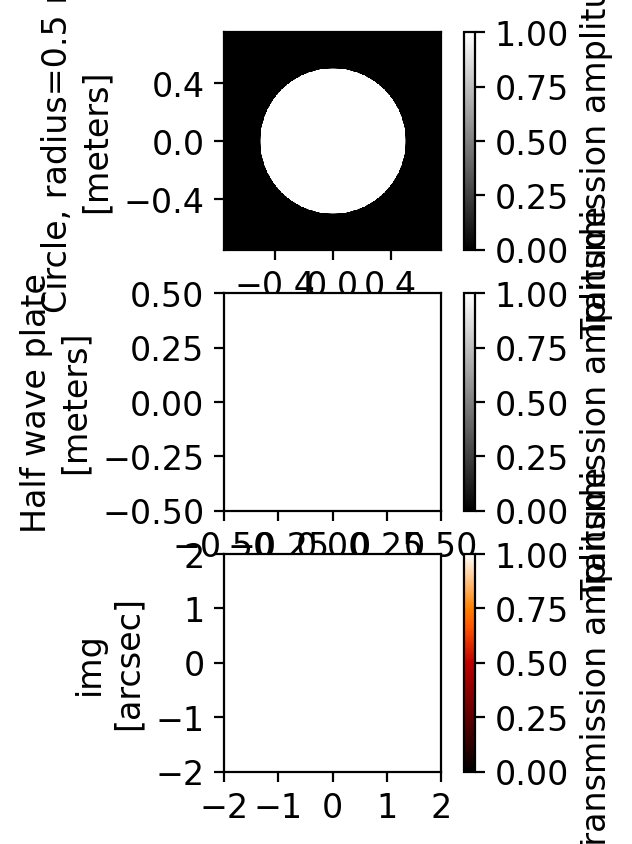

In [4]:
osys.display()

tensor_idx not provided! Plotting 0 element of vector/tensor field.
tensor_idx not provided! Plotting 0 element of vector/tensor field.


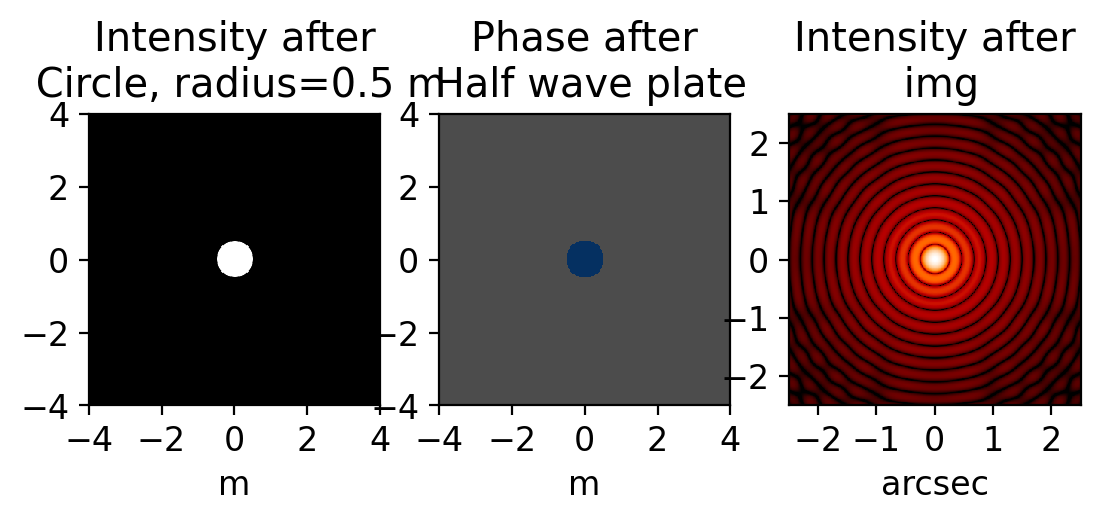

In [5]:
psf, wfs = osys.calc_psf(inwave=wf, return_intermediates=True, display_intermediates=True)

Display the intensity, defined as: $I = |E_x|^2 + |E_y|^2$

<Axes: title={'center': 'Intensity after\n img'}, xlabel='arcsec'>

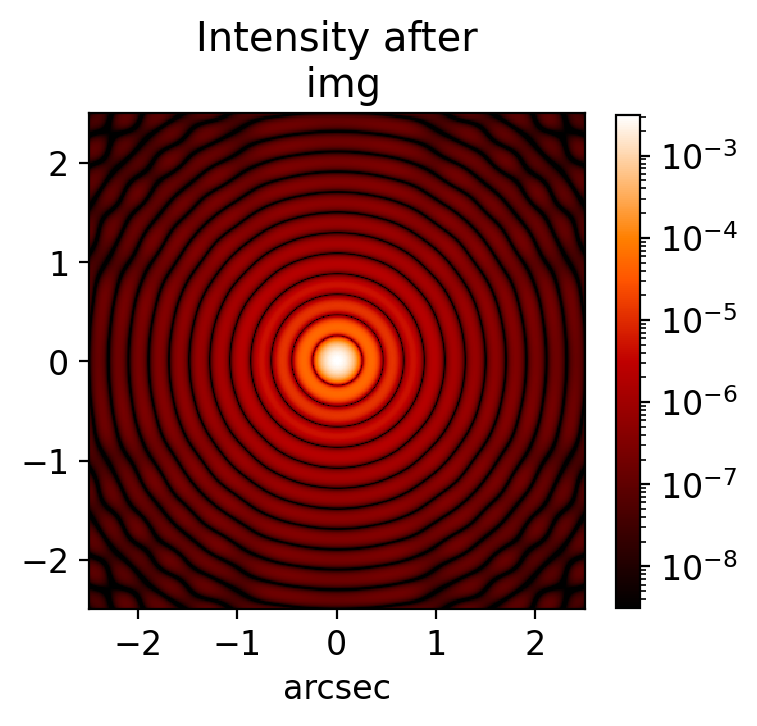

In [6]:
fig = plt.figure(figsize=(4,4))
wfs[-1].display(what='intensity', colorbar=True)

...and the intensity in the individual orthogonal polarization states.

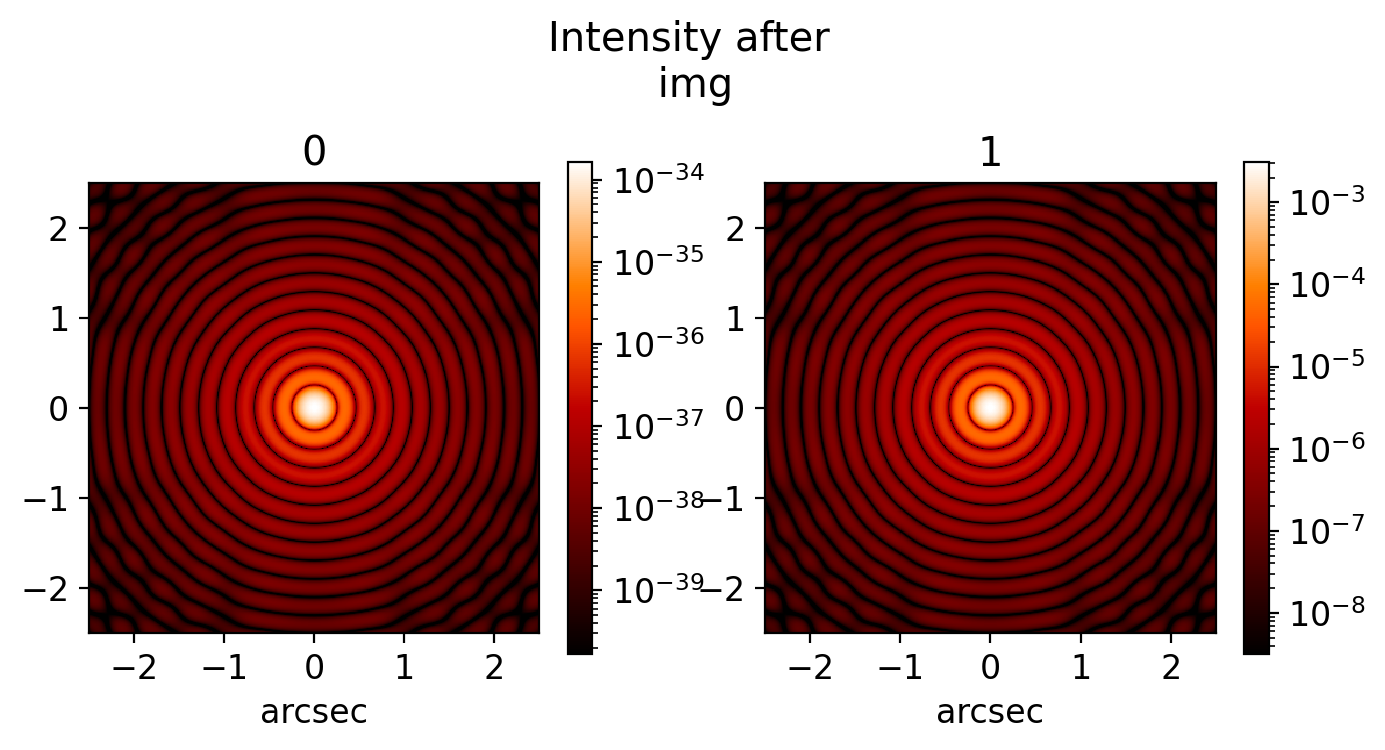

In [7]:
fig = plt.figure(figsize=(8,4))
out = wfs[-1].display_tensor(what='intensity', colorbar=True)

# Partial Polarization

Tensor diffraction with Stokes parameters through a Fresnel optical system.

This sends an unpolarized field through a linear polarizer and quarterwave plate pair and shows that the output stokes vector has converted to circular.

In [8]:
npix = 256
D = 10 * u.mm
wavelen = 630* u.nm

input_stokes_vector = (1, 0, 0, 0) # unpolarized input
wf = poppy.PolarizedFresnelWavefront(D, wavelength=wavelen, npix=npix, input_stokes_vector=input_stokes_vector)

In [9]:
circ = poppy.CircularAperture(radius=D/2)
tl = poppy.QuadraticLens(f_lens=300*u.mm)
# filter unpolarized input for circular polarization
lp = poppy.LinearPolarizer(angle=0)
qwp = poppy.QuarterWavePlate(angle=-xp.pi/4)
#cp = poppy.CircularPolarizer('right')

osys = poppy.FresnelOpticalSystem(npix=npix, pupil_diameter=D)
osys.add_optic(circ)
osys.add_optic(tl)
osys.add_optic(lp, distance=280*u.mm)
osys.add_optic(qwp, distance=10*u.mm)
#osys.add_optic(cp)

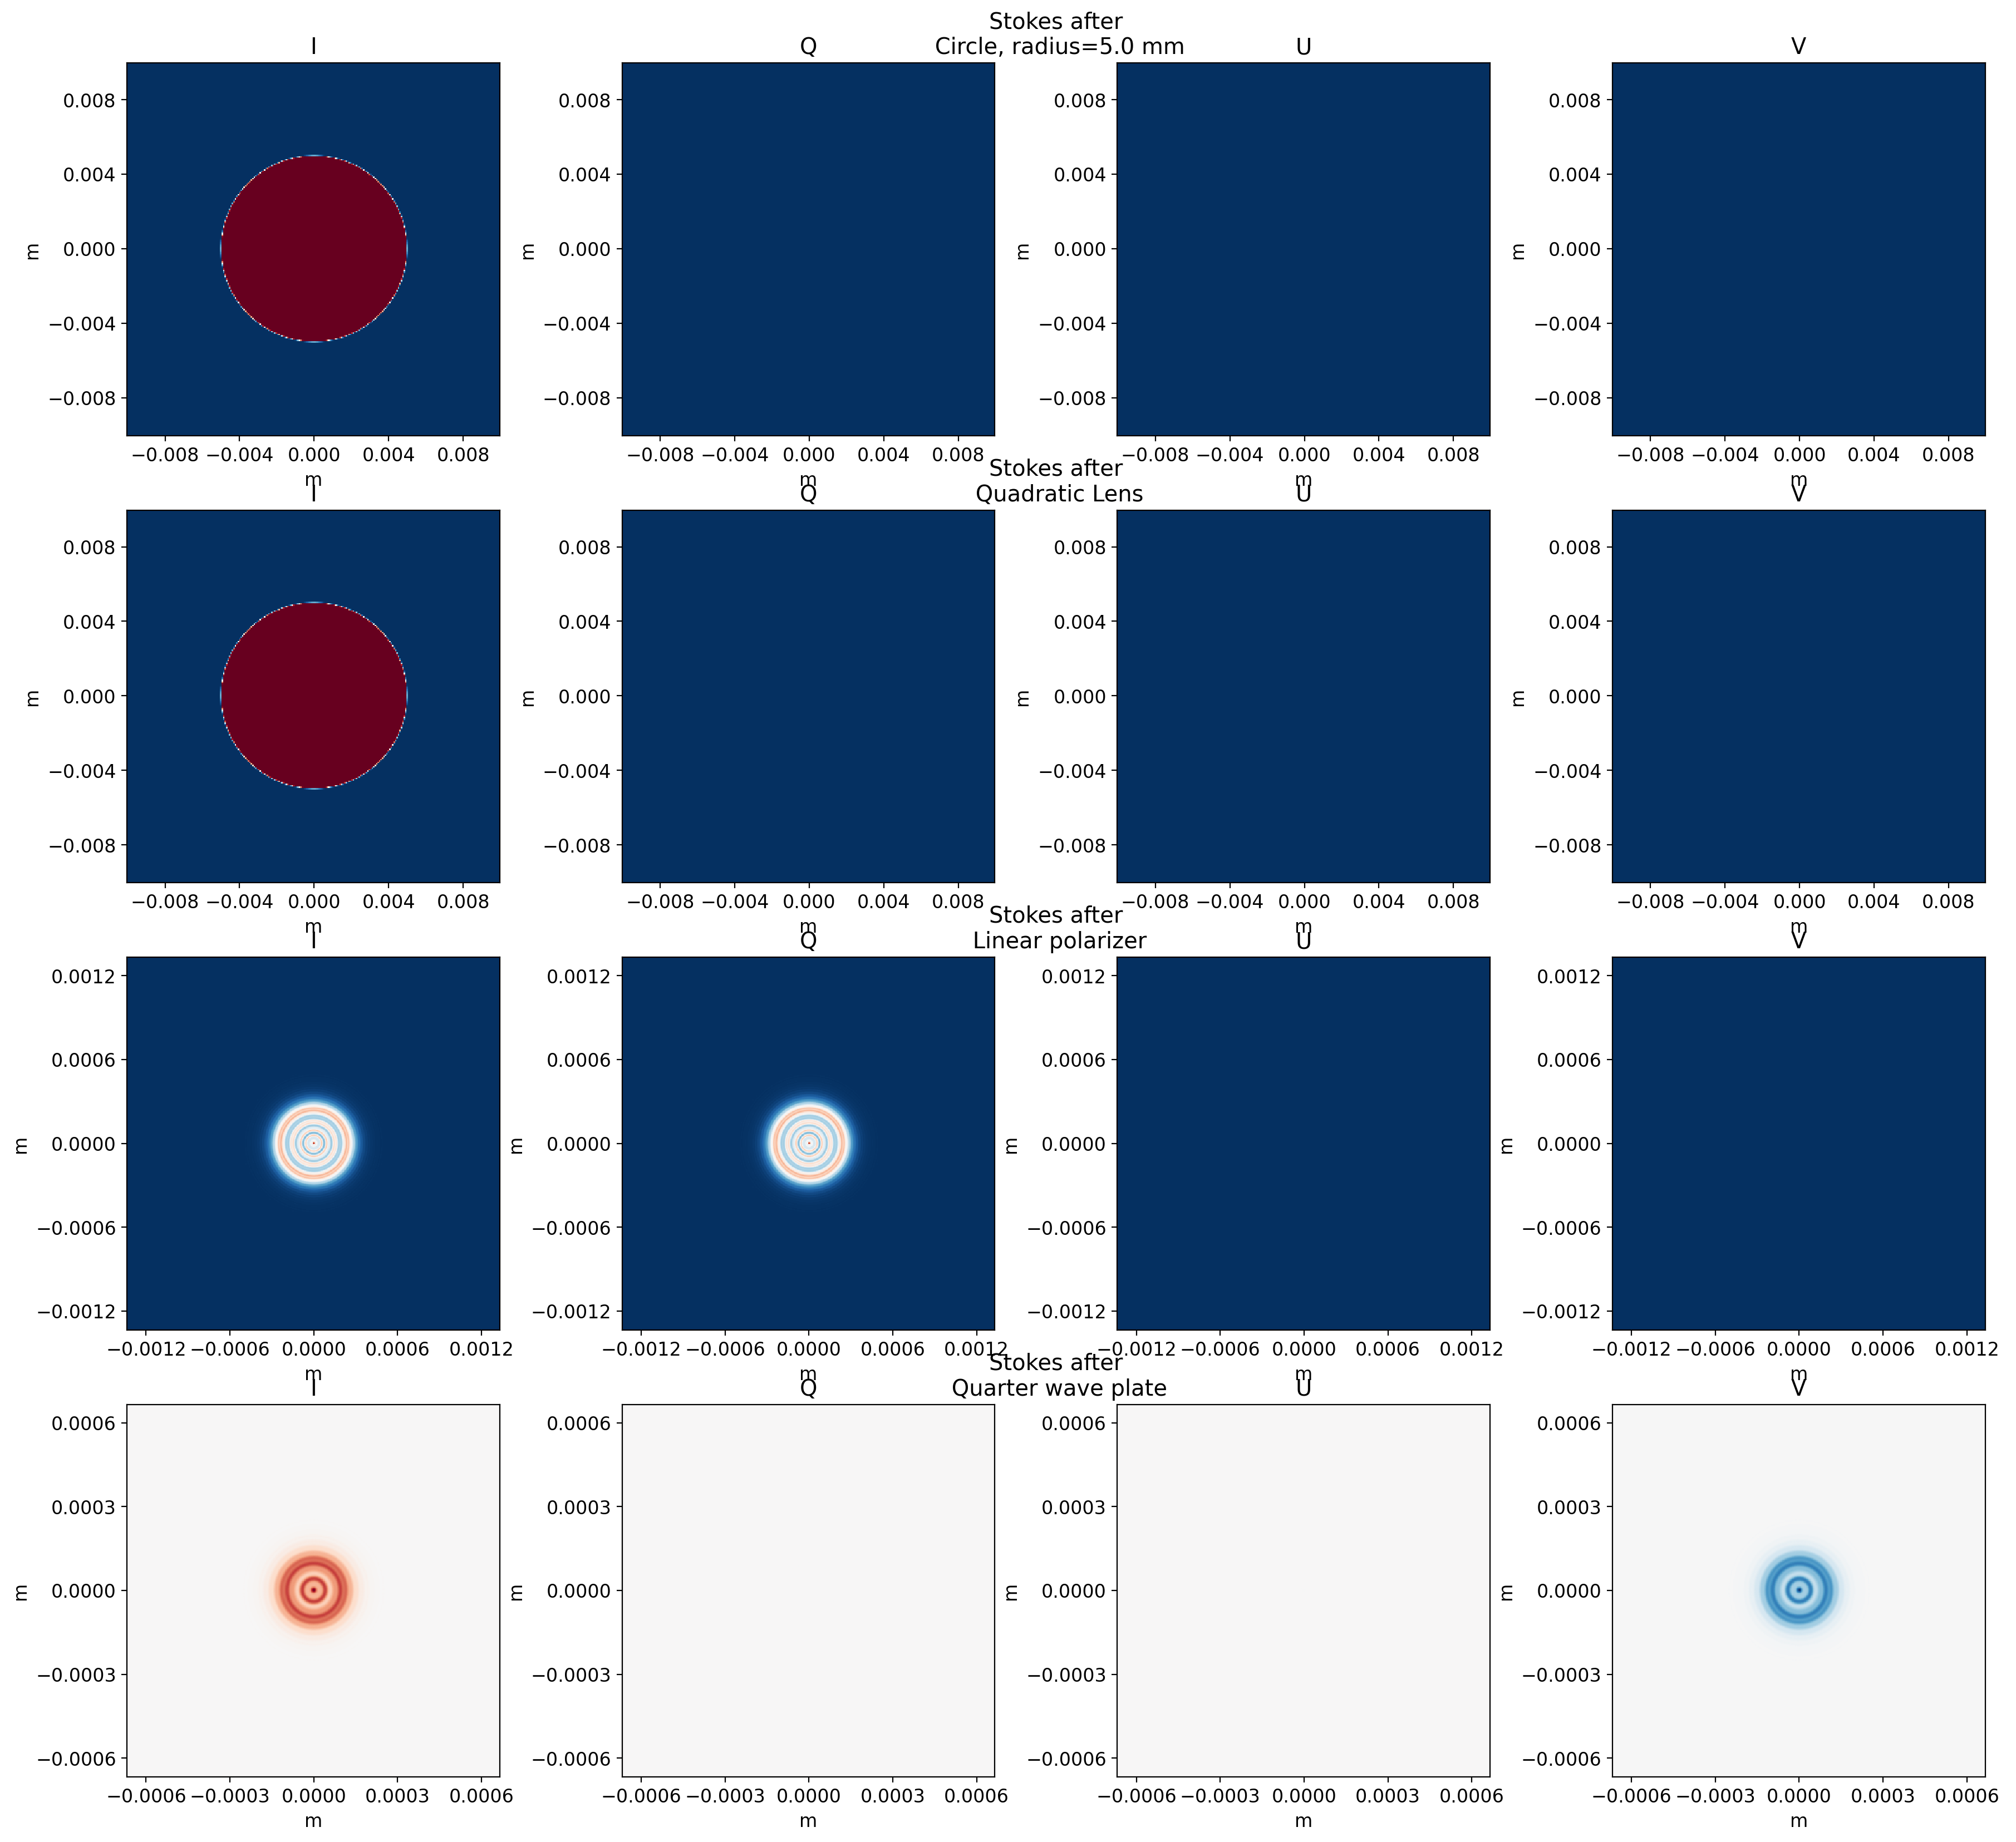

In [10]:
plt.figure(figsize=(22,20))
psf, wfs = osys.calc_psf(inwave=wf, return_intermediates=True, display_intermediates=True)

Display the intensity (I element of the output Stokes parameters)

<Axes: title={'center': 'Intensity after\n Quarter wave plate'}, xlabel='m'>

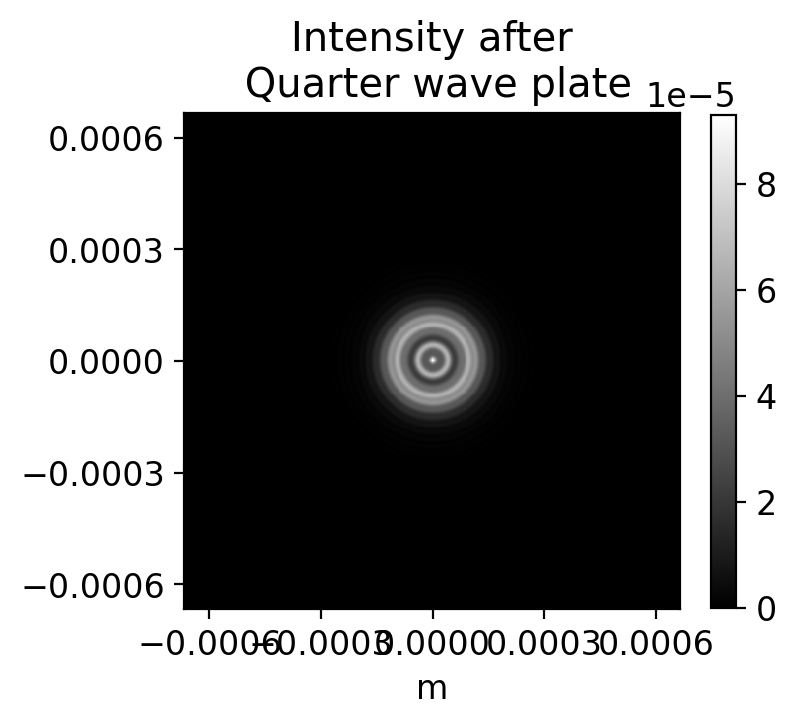

In [11]:
fig = plt.figure(figsize=(4,4))
wfs[-1].display(what='intensity', colorbar=True)

...and the tensor field.

/Users/kvangorkom/anaconda3/envs/poppypol/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/kvangorkom/anaconda3/envs/poppypol/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/kvangorkom/anaconda3/envs/poppypol/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/kvangorkom/anaconda3/envs/poppypol/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


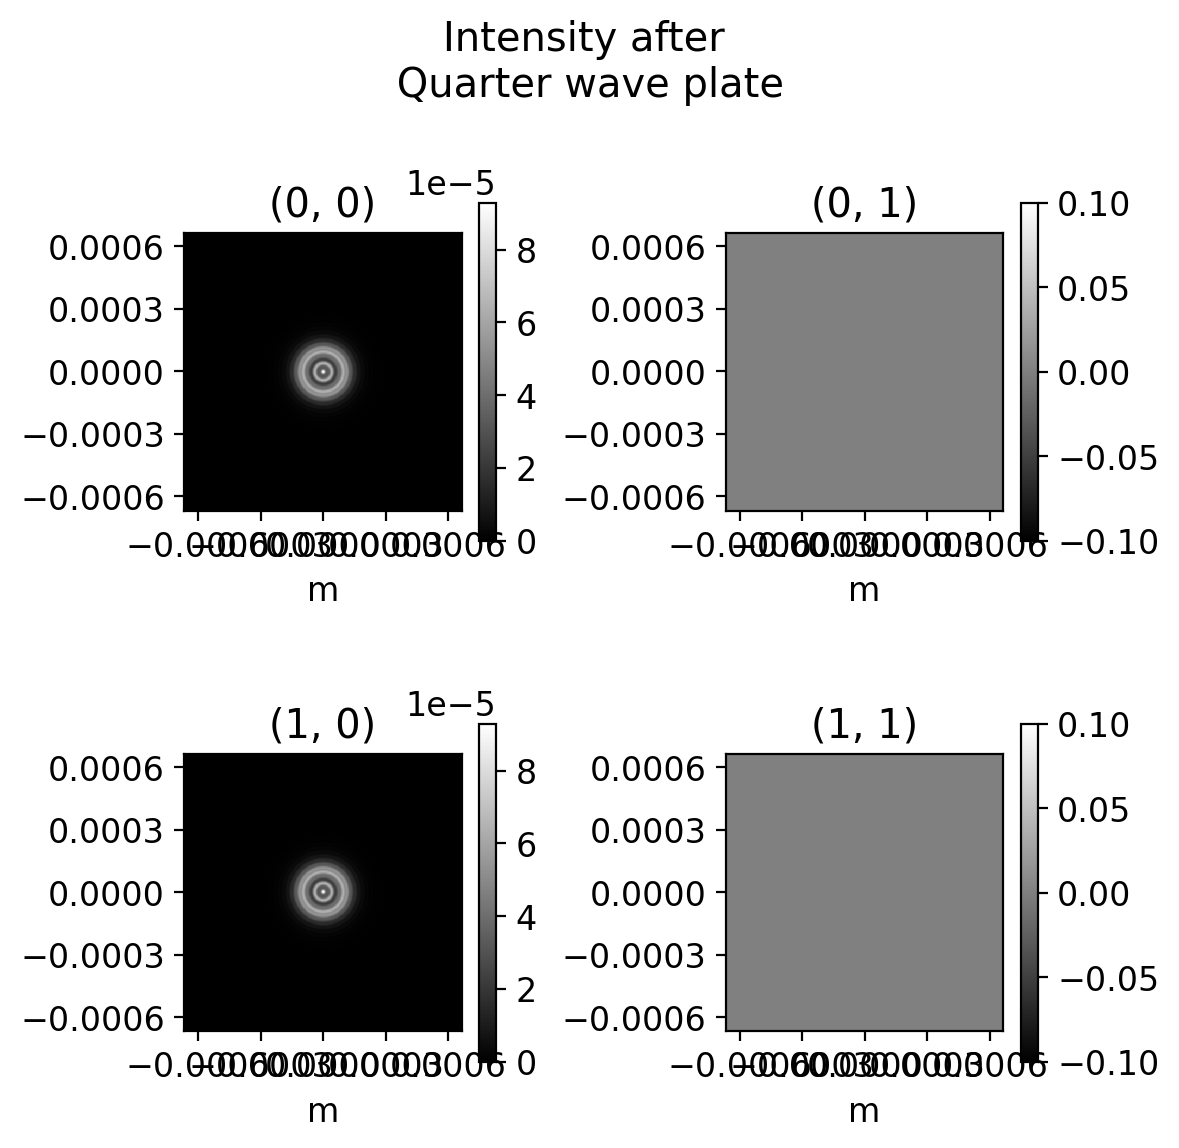

In [12]:
fig = plt.figure(figsize=(6,6))
wfs[-1].display_tensor(what='intensity', colorbar=True)
fig.tight_layout()

And, finally, plot the stokes parameters.

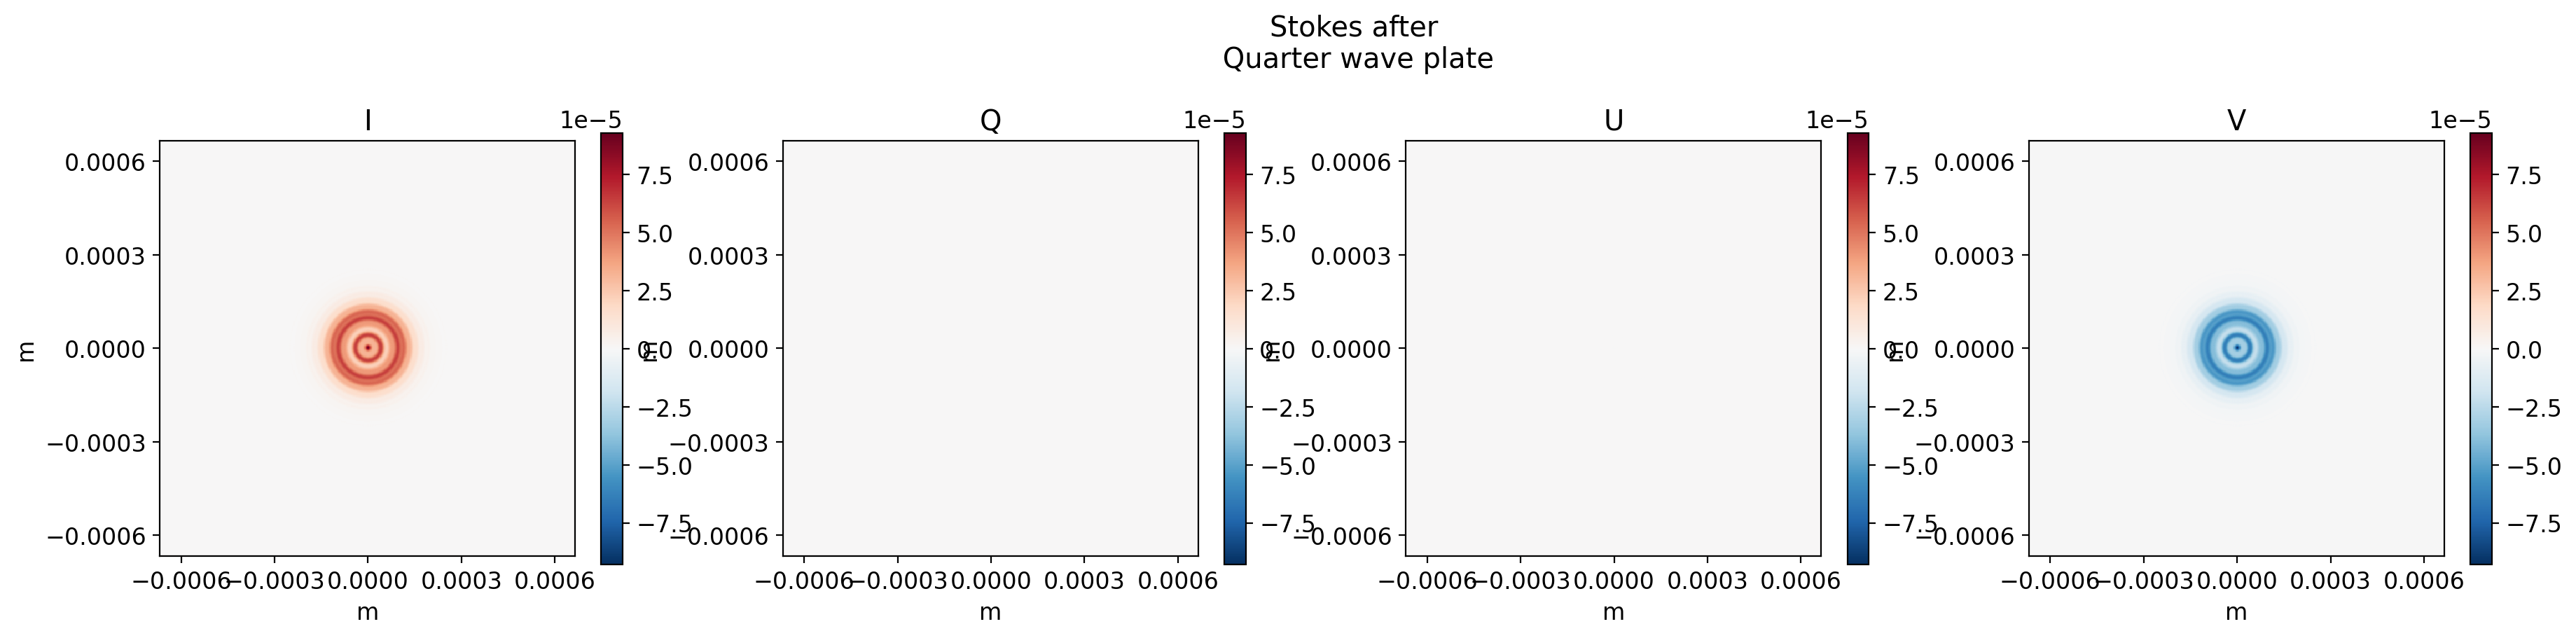

In [13]:
fig = plt.figure(figsize=(22,5))
axes = wfs[-1].display(what='stokes', colorbar=True)

# Simple coronagraph example

An unpolarized field through a coronagraph system with a charge-6 vector vortex coronagraph (VVC) with polarization filtering.

Errors are introduced on the VVC retardance and QWP in the input circular polarizer to demonstrate leakage filtering.

In [14]:
npix = 512
D = 1 * u.m
wavelen = 1e-6 * u.m
input_stokes_vector = (1, 0, 0, 0) # unpolarized input

In [15]:
osys = poppy.OpticalSystem(npix=npix)

circ = poppy.CircularAperture(radius=D/2)
lyot = poppy.CircularAperture(radius=D/2*0.9, name='lyot')
ttm = poppy.TipTiltStage(optic=circ, radius=D/2)

lp_in = poppy.LinearPolarizer(angle=0)
qwp_in = poppy.QuarterWavePlate(angle=-xp.pi/4*0.95) # error on the QWP clocking

vvc = poppy.SimpleVectorVortexMask(charge=6, retardance=xp.pi*0.95) # VVC with a global retardance error to create a leakage term
ep = poppy.ScalarTransmission(name='pupil')

lp_out = poppy.LinearPolarizer(angle=0)
qwp_out = poppy.QuarterWavePlate(angle=-xp.pi/4)

# circular aperture
osys.add_pupil(circ)
osys.add_pupil(ttm)

# circular polarizer
osys.add_pupil(lp_in)
osys.add_pupil(qwp_in)

# apply VVC (~halfwave plate, so should see circular handedness flip)
osys.add_image(vvc)

# to exit pupil
osys.add_pupil(ep)

# lyot stop
osys.add_pupil(lyot)

# circular analyzer
osys.add_pupil(qwp_out)
osys.add_pupil(lp_out)

# final focal plane
osys.add_detector(0.1*u.arcsec/u.pixel, fov_arcsec=5*u.arcsec)

# slow, but it improves the VVC singularity sampling a bit
osys_mft = poppy.MatrixFTCoronagraph(osys, oversample=64, occulter_box=3.0)

In [16]:
#osys.display()

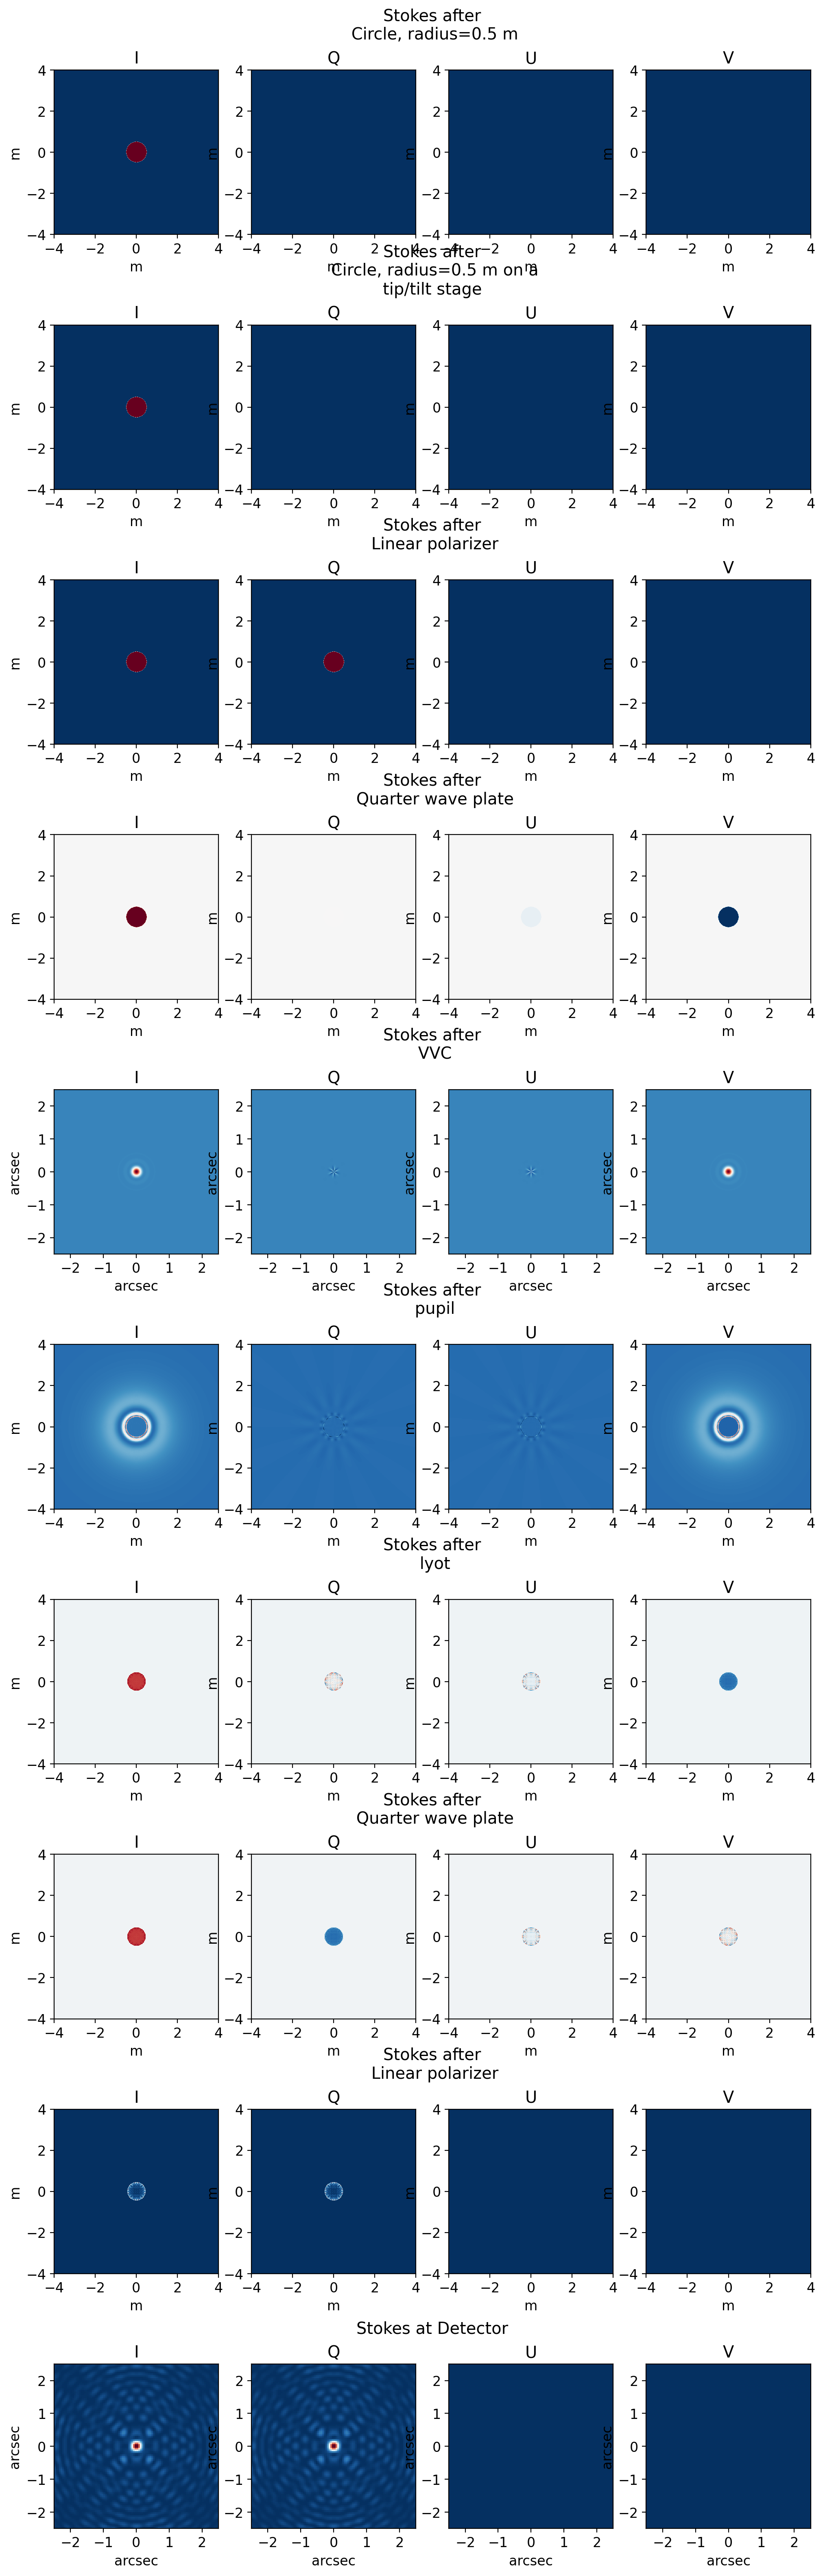

In [17]:
wf = poppy.PolarizedWavefront(npix=npix, input_stokes_vector=input_stokes_vector)

plt.figure(figsize=(12,40))
psf, wfs = osys_mft.calc_psf(inwave=wf, return_intermediates=True, display_intermediates=True)

<Axes: title={'center': 'Intensity at Detector'}, xlabel='arcsec'>

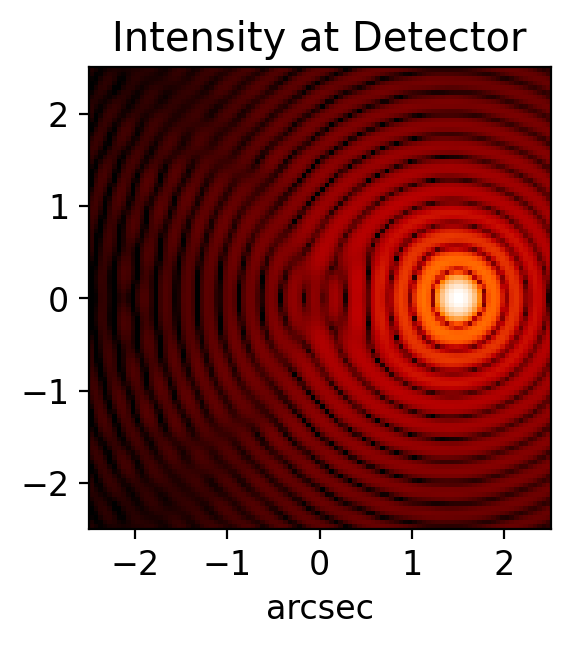

In [18]:
# get normalization from off-axis PSF
ttm.set_tip_tilt(1.5*u.arcsec, 0*u.arcsec)

wf = poppy.PolarizedWavefront(npix=npix, input_stokes_vector=input_stokes_vector)
psf_offaxis, wf_offaxis = osys.calc_psf(inwave=wf, return_final=True) # can't use SAM because PSF is too far off-axis
norm = wf_offaxis[0].intensity.max()

fig = plt.figure(figsize=(3,3))
wf_offaxis[0].display(what='intensity')

Plot the contrast

(the on-axis residual is dominated by the leakage term, the off-axis speckles are primarily due to poor sampling of the VVC singularity)

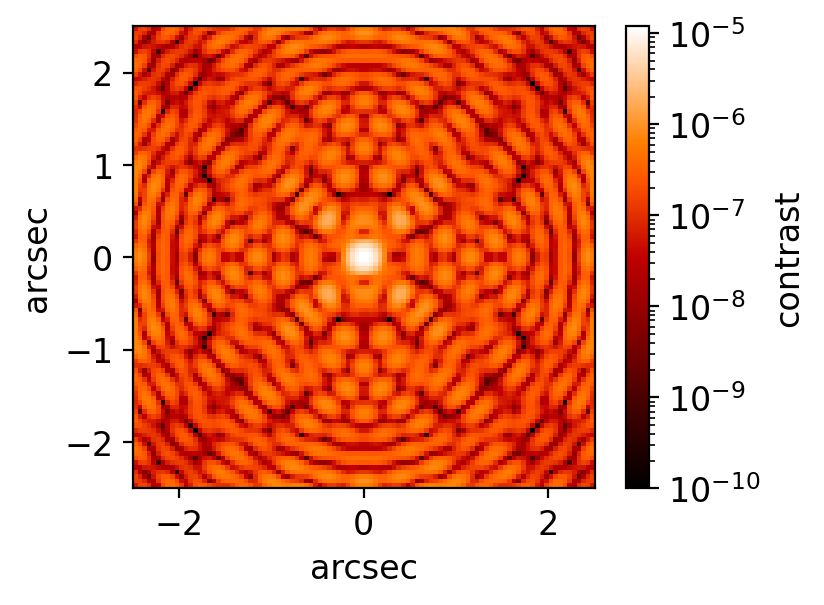

In [19]:
contrast = wfs[-1].intensity / norm
half_extent = (wfs[-1].shape[0] * wfs[-1].pixelscale / 2).value # arcsec
extent = [-half_extent, half_extent, -half_extent, half_extent]

fig = plt.figure(figsize=(4,3))
plt.imshow(contrast, norm=LogNorm(vmin=1e-10), extent=extent, cmap='gist_heat')
plt.xlabel('arcsec')
plt.ylabel('arcsec')
plt.colorbar().set_label('contrast')